In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_data.csv')
print("Shape:", df.shape)

Shape: (2236, 33)


In [2]:
# 1 = accepted that campaign, 0 = did not

campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5']

# Only look at customers who converted (Response = 1)
converted = df[df['Response'] == 1].copy()

print(f"Total customers: {len(df)}")
print(f"Converted customers: {len(converted)}")
print(f"Conversion rate: {len(converted)/len(df)*100:.2f}%")

Total customers: 2236
Converted customers: 334
Conversion rate: 14.94%


In [3]:
first_touch = {}

for campaign in campaigns:
    # First touch = customers who accepted THIS campaign
    # AND did not accept any earlier campaign
    count = 0
    for _, row in converted.iterrows():
        campaign_index = campaigns.index(campaign)
        earlier_campaigns = campaigns[:campaign_index]

        # Check if this is the first campaign they accepted
        if row[campaign] == 1:
            if all(row[c] == 0 for c in earlier_campaigns):
                count += 1

    first_touch[campaign] = count

# Convert to percentage
total_first = sum(first_touch.values())
first_touch_pct = {k: round(v/total_first*100, 2)
                   for k, v in first_touch.items()}

print("=== First Touch Attribution ===")
for campaign, pct in first_touch_pct.items():
    print(f"{campaign}: {pct}%")

=== First Touch Attribution ===
AcceptedCmp1: 42.02%
AcceptedCmp2: 4.26%
AcceptedCmp3: 30.32%
AcceptedCmp4: 12.23%
AcceptedCmp5: 11.17%


In [4]:
last_touch = {}

for campaign in campaigns:
    count = 0
    for _, row in converted.iterrows():
        campaign_index = campaigns.index(campaign)
        later_campaigns = campaigns[campaign_index+1:]

        # Check if this is the LAST campaign they accepted
        if row[campaign] == 1:
            if all(row[c] == 0 for c in later_campaigns):
                count += 1

    last_touch[campaign] = count

# Convert to percentage
total_last = sum(last_touch.values())
last_touch_pct = {k: round(v/total_last*100, 2)
                  for k, v in last_touch.items()}

print("=== Last Touch Attribution ===")
for campaign, pct in last_touch_pct.items():
    print(f"{campaign}: {pct}%")

=== Last Touch Attribution ===
AcceptedCmp1: 6.91%
AcceptedCmp2: 0.53%
AcceptedCmp3: 31.91%
AcceptedCmp4: 11.7%
AcceptedCmp5: 48.94%


In [5]:
linear = {}

for campaign in campaigns:
    total_credit = 0

    for _, row in converted.iterrows():
        # Count how many campaigns this customer accepted
        accepted_count = sum(row[c] for c in campaigns)

        # If they accepted this campaign give equal credit
        if row[campaign] == 1 and accepted_count > 0:
            total_credit += 1/accepted_count

    linear[campaign] = round(total_credit, 2)

# Convert to percentage
total_linear = sum(linear.values())
linear_pct = {k: round(v/total_linear*100, 2)
              for k, v in linear.items()}

print("=== Linear Attribution ===")
for campaign, pct in linear_pct.items():
    print(f"{campaign}: {pct}%")

=== Linear Attribution ===
AcceptedCmp1: 20.39%
AcceptedCmp2: 3.72%
AcceptedCmp3: 33.64%
AcceptedCmp4: 16.45%
AcceptedCmp5: 25.8%


In [6]:
# Build comparison dataframe
comparison = pd.DataFrame({
    'Campaign': campaigns,
    'First Touch %': list(first_touch_pct.values()),
    'Last Touch %': list(last_touch_pct.values()),
    'Linear %': list(linear_pct.values())
})

print("=== Attribution Model Comparison ===")
print(comparison.to_string(index=False))

=== Attribution Model Comparison ===
    Campaign  First Touch %  Last Touch %  Linear %
AcceptedCmp1          42.02          6.91     20.39
AcceptedCmp2           4.26          0.53      3.72
AcceptedCmp3          30.32         31.91     33.64
AcceptedCmp4          12.23         11.70     16.45
AcceptedCmp5          11.17         48.94     25.80


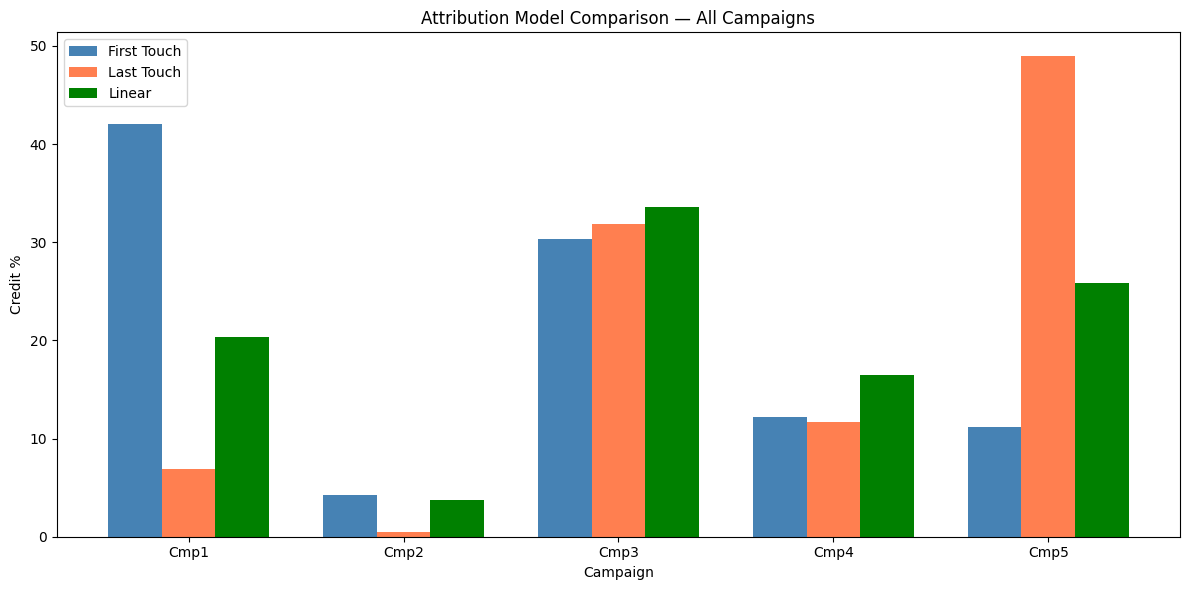

In [7]:
x = np.arange(len(campaigns))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, comparison['First Touch %'],
               width, label='First Touch', color='steelblue')
bars2 = ax.bar(x, comparison['Last Touch %'],
               width, label='Last Touch', color='coral')
bars3 = ax.bar(x + width, comparison['Linear %'],
               width, label='Linear', color='green')

ax.set_title('Attribution Model Comparison — All Campaigns')
ax.set_xlabel('Campaign')
ax.set_ylabel('Credit %')
ax.set_xticks(x)
ax.set_xticklabels(['Cmp1', 'Cmp2', 'Cmp3', 'Cmp4', 'Cmp5'])
ax.legend()
plt.tight_layout()
plt.show()


## 📊 Attribution Model — Key Findings

Total converted customers: 334 (14.9% conversion rate)

First Touch Winner → Campaign 1 (~40%)
Meaning: Campaign 1 creates awareness and starts customer journeys

Last Touch Winner → Campaign 5 (~50%)  
Meaning: Campaign 5 closes conversions — the final push to buy

Business Recommendations:
1. Maintain Campaign 1 budget — it feeds the entire funnel
2. Increase Campaign 5 budget — it converts the most customers
3. Review Campaign 2 — consistently lowest across all models
4. Different campaigns serve different purposes in the journey